# Model Experiments: Trial Comparison and Final Selection

This notebook supports the evaluation responsibility to:

- compare trial runs,
- visualize Optuna/trial optimization history,
- show final model-selection rationale.

It first tries to load `artifacts/evaluation/mlflow_run_comparison.csv` (exported by `evaluate.py`).
If unavailable, it can query MLflow directly when configured.

In [ ]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None

try:
    import mlflow
except Exception:
    mlflow = None


def find_project_root() -> Path:
    """Find repo root by searching for pyproject.toml from cwd upward."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()

if load_dotenv is not None:
    load_dotenv(PROJECT_ROOT / ".env", override=False)

CSV_PATH = PROJECT_ROOT / "artifacts/evaluation/mlflow_run_comparison.csv"
EXPERIMENT_NAME = os.getenv("MLFLOW_EXPERIMENT_NAME", "foresight-training")
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "")

if TRACKING_URI and mlflow is not None:
    print(f"Tracking server: {TRACKING_URI}")
    mlflow.set_tracking_uri(TRACKING_URI)

print(f"Project root: {PROJECT_ROOT}")
print(f"CSV path: {CSV_PATH}")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Tracking URI set: {bool(TRACKING_URI)}")
print(f"MLflow available: {mlflow is not None}")

/Users/bryanzeng/Desktop/IE7374/foresight_ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tracking server: https://foresight-mlflow-6ool3rlbea-uc.a.run.app
Project root: /Users/bryanzeng/Desktop/IE7374/foresight_ml
CSV path: /Users/bryanzeng/Desktop/IE7374/foresight_ml/artifacts/evaluation/mlflow_run_comparison.csv
Experiment: foresight-training
Tracking URI set: True
MLflow available: True


In [2]:
def load_run_comparison() -> pd.DataFrame:
    """Prefer MLflow run history; fall back to CSV export if needed."""
    mlflow_df = pd.DataFrame()

    if mlflow is not None:
        experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
        if experiment is not None:
            mlflow_df = mlflow.search_runs(
                experiment_ids=[experiment.experiment_id],
                order_by=["attribute.start_time ASC"],
            )
            if not mlflow_df.empty:
                print(f"Loaded {len(mlflow_df)} runs from MLflow.")
                return mlflow_df
        else:
            print(
                "MLflow experiment not found at current tracking URI. "
                "If you expect remote runs, set MLFLOW_TRACKING_URI and re-run cell 1."
            )

    if CSV_PATH.exists():
        csv_df = pd.read_csv(CSV_PATH)
        print(f"Loaded {len(csv_df)} runs from CSV fallback.")
        if len(csv_df) <= 1:
            print(
                "Only one run found in CSV. For full trial history, set MLFLOW_TRACKING_URI "
                "to your tracking server and re-run cell 1."
            )
        return csv_df

    print("No run history found. Run train/evaluate pipeline first.")
    return pd.DataFrame()


runs = load_run_comparison()
metric_cols = [c for c in runs.columns if c.startswith("metrics.")]
display_cols = ["run_id", "status", "start_time", "end_time"] + metric_cols[:8]

if runs.empty:
    print("No runs available yet. Execute train/evaluate pipeline to generate runs.")
else:
    display(runs[display_cols].head(20))

Loaded 56 runs from MLflow.


,run_id,status,start_time,end_time,metrics.val_roc_auc,metrics.train_time_sec
0,8b712021211f4a6583b84a1f77561d90,FAILED,2026-03-16 19:15:24.229000+00:00,2026-03-16 19:15:24.354000+00:00,NaN,NaN
1,364774ea71d044e7974b44cc63ebc79e,FAILED,2026-03-16 19:18:56.654000+00:00,2026-03-16 19:18:56.790000+00:00,NaN,NaN
2,80e4d80448c44370885600f76488b3a4,FINISHED,2026-03-16 19:23:07.958000+00:00,2026-03-16 19:23:48.543000+00:00,0.974616,NaN
3,4e568f40b4c1418299049f106e50c2b0,FINISHED,2026-03-16 19:23:48.755000+00:00,2026-03-16 19:50:17.752000+00:00,NaN,NaN
4,fa07846db80f440ca841eb38febdd2ab,FINISHED,2026-03-16 19:23:48.852000+00:00,2026-03-16 19:26:22.561000+00:00,0.973545,152.930719
5,abf4f40da714414fb8fc5bc4a6632ce3,FINISHED,2026-03-16 19:26:22.732000+00:00,2026-03-16 19:26:49.611000+00:00,0.976685,26.160584
6,cff8883bf09b4e2095d6cb923e49cd82,FINISHED,2026-03-16 19:26:49.785000+00:00,2026-03-16 19:27:16.566000+00:00,0.976703,26.060122
7,d2ac7826ecfa49b5bdbe302aa04752b2,FINISHED,2026-03-16 19:27:16.754000+00:00,2026-03-16 19:28:03.578000+00:00,0.977354,45.865353
8,85704e927a1b4023bf2afaf7eb1a408d,FINISHED,2026-03-16 19:28:03.804000+00:00,2026-03-16 19:28:32.851000+00:00,0.976300,28.337307
9,4b7ebdd6102c40c186e6ee65766bb6d0,FINISHED,2026-03-16 19:28:33.034000+00:00,2026-03-16 19:29:02.768000+00:00,0.977569,28.973454


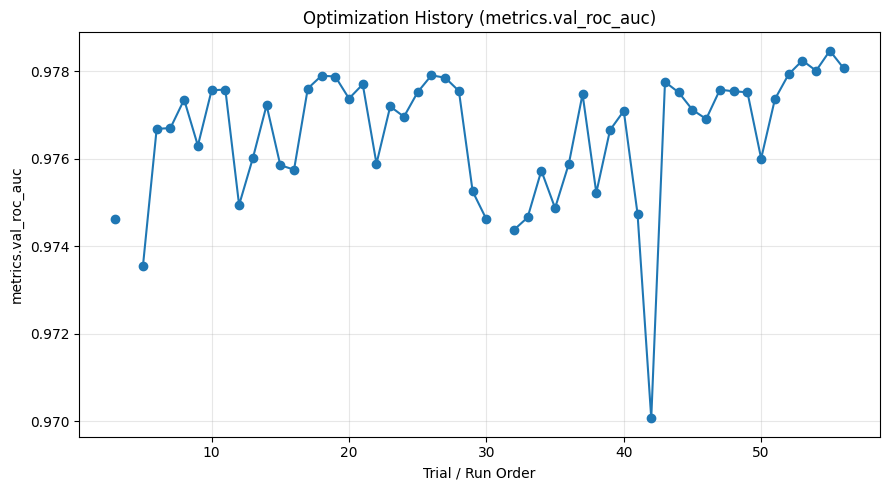

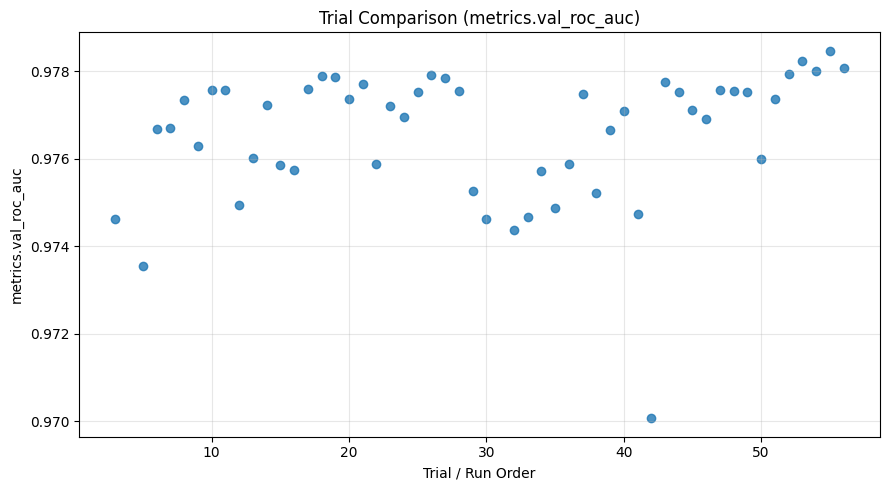

In [3]:
def pick_metric_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "metrics.val_roc_auc",
        "metrics.test_roc_auc",
        "metrics.test_f1_at_tuned_threshold",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None


if runs.empty:
    print("Skipping plots: no runs loaded.")
else:
    metric_col = pick_metric_column(runs)
    if metric_col is None:
        print("No supported metric column found for plotting.")
    else:
        chart_df = runs.copy()
        if "start_time" in chart_df.columns:
            chart_df = chart_df.sort_values("start_time")
        chart_df = chart_df.reset_index(drop=True)
        chart_df["trial_index"] = chart_df.index + 1

        if len(chart_df) < 2:
            print(
                "Only one run available, so the chart shows a single point. "
                "Log more runs (or connect to the correct MLflow tracking URI) for a trend line."
            )

        plt.figure(figsize=(9, 5))
        plt.plot(chart_df["trial_index"], chart_df[metric_col], marker="o")
        plt.title(f"Optimization History ({metric_col})")
        plt.xlabel("Trial / Run Order")
        plt.ylabel(metric_col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(9, 5))
        plt.scatter(chart_df["trial_index"], chart_df[metric_col], alpha=0.8)
        plt.title(f"Trial Comparison ({metric_col})")
        plt.xlabel("Trial / Run Order")
        plt.ylabel(metric_col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [4]:
if runs.empty:
    print("No rationale available: no runs found.")
else:
    rank_metric = None
    for col in ["metrics.test_roc_auc", "metrics.val_roc_auc", "metrics.test_f1_at_tuned_threshold"]:
        if col in runs.columns:
            rank_metric = col
            break

    if rank_metric is None:
        print("No ranking metric available in runs.")
    else:
        ranked = runs.sort_values(rank_metric, ascending=False).reset_index(drop=True)
        top = ranked.iloc[0]

        print("Final model selection rationale")
        print("- Primary ranking metric:", rank_metric)
        print("- Selected run_id:", top.get("run_id", "unknown"))
        print("- Best metric value:", top.get(rank_metric, float("nan")))

        secondary = [
            c
            for c in [
                "metrics.test_brier_score",
                "metrics.test_precision_at_5pct",
                "metrics.test_recall_at_5pct",
                "metrics.test_f1_at_tuned_threshold",
            ]
            if c in ranked.columns
        ]
        if secondary:
            print("- Secondary checks:")
            for col in secondary:
                print(f"  - {col}: {top[col]}")

        cols = ["run_id", rank_metric] + secondary
        display(ranked[cols].head(10))

Final model selection rationale
- Primary ranking metric: metrics.val_roc_auc
- Selected run_id: fb088776274942b688f3d6c7fc8dccf6
- Best metric value: 0.9784733221965443


,run_id,metrics.val_roc_auc
0,fb088776274942b688f3d6c7fc8dccf6,0.978473
1,ab688e2c92ea46fc975945130430b989,0.978249
2,75da7693085849afb97860fbf382c5af,0.978073
3,f739e1952e904e7e8ebb83f8597b66b0,0.978015
4,cefb251ae2e2444ea6b3c351ff257a15,0.977934
5,11dd01c1ceaa47cc9715cbba18b137b6,0.977911
6,6a4f015a25174538a5363fd59c8fa020,0.977902
7,19cdf073e7b742b2993aa7e9e40974fd,0.977883
8,af2f07e9ddac45db90915cbc3e601551,0.977855
9,04e6dd336f254b79978ec5086805c191,0.977759


## Deployment Readiness: MLflow Registry Consistency

Verifies that the production model registered in the MLflow registry (via the `champion` alias)
is consistent with local experiment artifacts — run ID, GCS artifact path, and test ROC-AUC.

In [ ]:
import os
import json as _json
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

MLFLOW_MODEL_NAME = os.getenv('MLFLOW_MODEL_NAME', 'foresight-distress-model')
MLFLOW_MODEL_ALIAS = os.getenv('MLFLOW_MODEL_ALIAS', 'champion')

_repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
_results_path = _repo_root / 'optuna_results.json'
local_test_roc = None
local_best_params = {}
if _results_path.exists():
    with open(_results_path) as _f:
        _r = _json.load(_f)
    local_test_roc = float(_r.get('test_roc_auc', 0))
    local_best_params = _r.get('best_params', {})

registry_checks = []

if mlflow is None:
    registry_checks.append({'check': 'MLflow import', 'value': 'mlflow not installed', 'status': 'SKIP'})
elif not TRACKING_URI:
    registry_checks.append({'check': 'MLflow registry connection', 'value': 'MLFLOW_TRACKING_URI not set', 'status': 'SKIP'})
else:
    try:
        from mlflow.tracking import MlflowClient
        client = MlflowClient()
        try:
            mv = client.get_model_version_by_alias(MLFLOW_MODEL_NAME, MLFLOW_MODEL_ALIAS)
            registry_checks.append({'check': 'Production model (champion alias)', 'value': f'v{mv.version}', 'status': 'PASS'})
            registry_checks.append({'check': 'Production run ID', 'value': mv.run_id, 'status': 'PASS'})
            registry_checks.append({'check': 'GCS artifact path', 'value': mv.source, 'status': 'PASS' if mv.source.startswith('gs://') else 'WARN'})
            prod_run = client.get_run(mv.run_id)
            mlflow_roc = prod_run.data.metrics.get('test_roc_auc')
            if mlflow_roc is not None and local_test_roc is not None:
                match = abs(mlflow_roc - local_test_roc) < 1e-4
                registry_checks.append({'check': 'test_roc_auc consistent', 'value': f'MLflow={mlflow_roc:.6f} | local={local_test_roc:.6f}', 'status': 'PASS' if match else 'FAIL'})
            mismatches = [f'{k}: local={v}, mlflow={prod_run.data.params.get(k)}'
                          for k, v in local_best_params.items()
                          if prod_run.data.params.get(k) and str(v) != str(prod_run.data.params.get(k))]
            registry_checks.append({'check': 'Best params consistent', 'value': 'All match' if not mismatches else '; '.join(mismatches), 'status': 'PASS' if not mismatches else 'WARN'})
        except Exception as e:
            registry_checks.append({'check': 'Champion alias lookup', 'value': str(e), 'status': 'FAIL'})
    except Exception as e:
        registry_checks.append({'check': 'MLflow registry connection', 'value': str(e), 'status': 'FAIL'})

pd.DataFrame(registry_checks)